In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
dataset = pd.read_csv('/content/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv')
dataset.sample(5)

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
4424,TXN04425,U04425,26,Female,8.73,2.72,0.39,5.47,5.15,136,36,9.35,Medium,Yes,Moderate,1
7033,TXN07034,U07034,28,Male,3.98,3.83,1.12,2.95,6.80,198,136,5.05,High,No,Mild,0
4674,TXN04675,U04675,26,Other,10.95,5.69,1.71,4.04,8.94,121,105,11.69,Low,No,Severe,1
3527,TXN03528,U03528,24,Other,3.58,2.13,2.32,2.45,8.81,33,27,4.44,High,Yes,Mild,0
874,TXN00875,U00875,29,Female,11.44,5.51,3.02,2.35,8.23,87,166,12.48,Low,No,Severe,1


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

In [5]:
info = pd.DataFrame({'dtype': dataset.dtypes, 'nulls': dataset.isnull().sum(), 'unique': dataset.nunique()})
print(info.to_string())

                           dtype  nulls  unique
transaction_id            object      0    7500
user_id                   object      0    7500
age                        int64      0      18
gender                    object      0       3
daily_screen_time_hours  float64      0     900
social_media_hours       float64      0     551
gaming_hours             float64      0     401
work_study_hours         float64      0     551
sleep_hours              float64      0     451
notifications_per_day      int64      0     231
app_opens_per_day          int64      0     166
weekend_screen_time      float64      0    1096
stress_level              object      0       3
academic_work_impact      object      0       2
addiction_level           object    819       3
addicted_label             int64      0       2


In [8]:
dataset['addiction_level'].unique()

array([nan, 'Mild', 'Moderate', 'Severe'], dtype=object)

In [9]:
dataset.fillna({'addiction': 'Unknown'}, inplace=True)

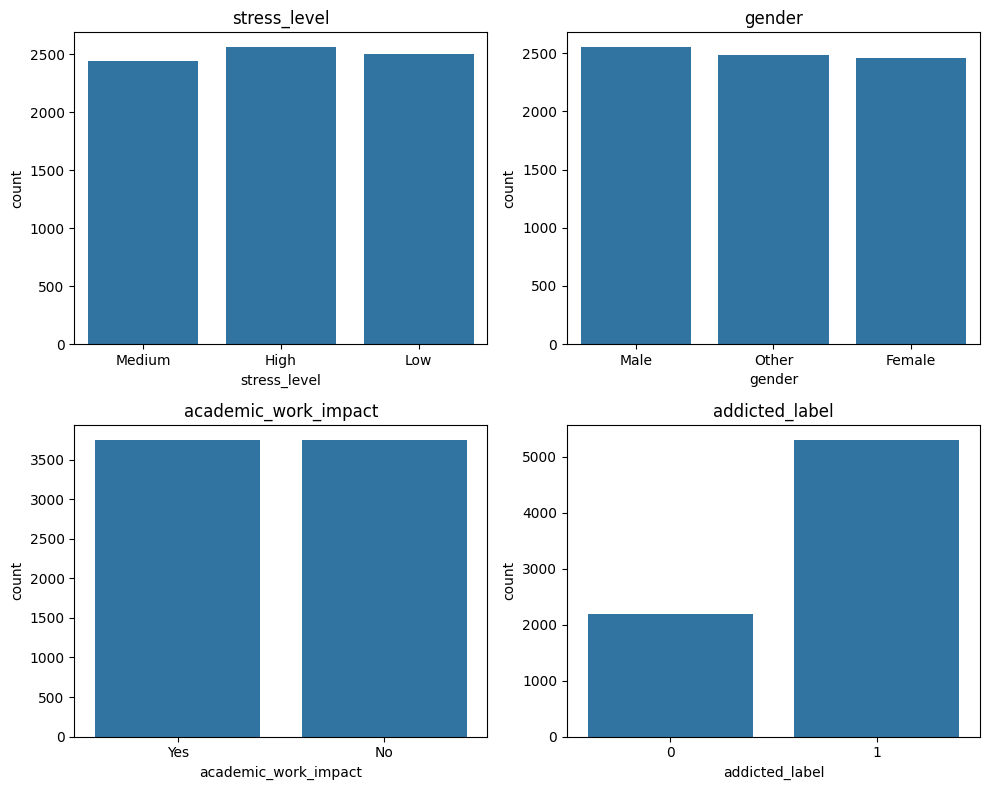

In [10]:
column_name = ['stress_level', 'gender', 'academic_work_impact','addicted_label']

plt.figure(figsize=(10, 8))
for idx, i in enumerate(column_name, 1):

    plt.subplot(2, 2, idx)
    sns.countplot(x=i, data=dataset)
    plt.title(i)


plt.tight_layout()
plt.show()

In [11]:
dataset = dataset.drop(['transaction_id','user_id'], axis = 1)

In [12]:
X = dataset.drop(['addicted_label','addiction_level'], axis = 1)
y = dataset['addicted_label']

In [13]:
X = pd.get_dummies(data = X, drop_first = True)

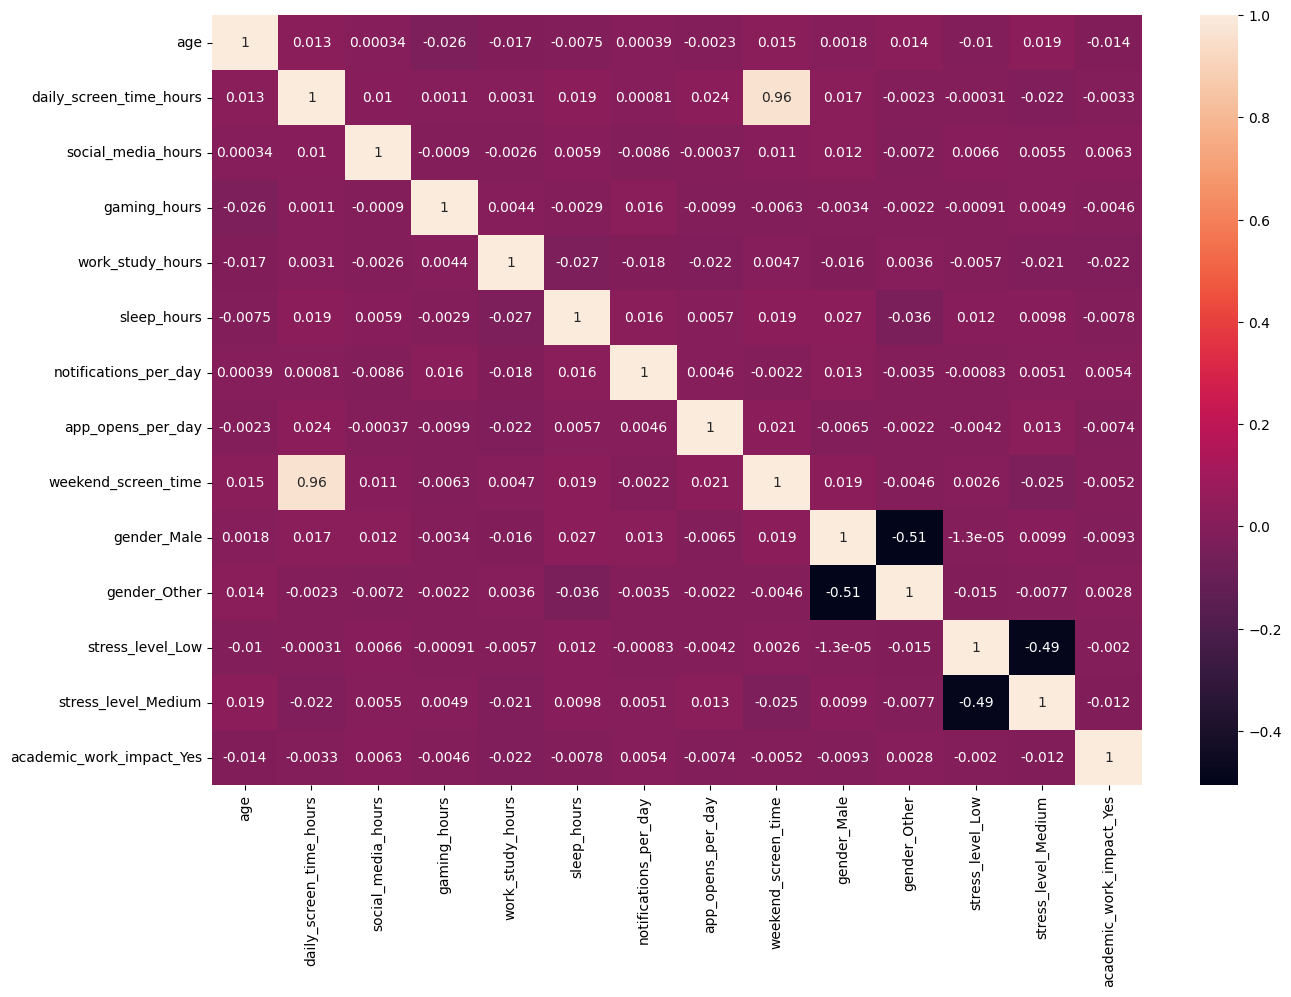

In [14]:
plt.figure(figsize = (15, 10))
sns.heatmap(X.corr(), annot = True)
plt.show()

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_sc = scaler.fit_transform(X)

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_sc, y, test_size = 0.2, random_state = 42)

In [18]:
from sklearn.linear_model import LogisticRegression
linr = LogisticRegression()

linr.fit(X_train, y_train)

LogisticRegression()

In [19]:
y_pred = linr.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy : ", accuracy_score(y_test, y_pred))
print("Classification Report :\n", classification_report(y_test, y_pred))

Accuracy :  0.8933333333333333
Classification Report :
               precision    recall  f1-score   support

           0       0.83      0.82      0.82       456
           1       0.92      0.93      0.92      1044

    accuracy                           0.89      1500
   macro avg       0.88      0.87      0.87      1500
weighted avg       0.89      0.89      0.89      1500



In [21]:
from sklearn.ensemble import RandomForestClassifier
forest = RandomForestClassifier(random_state = 42)

forest.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [22]:
y_pred = forest.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy : ", accuracy_score(y_test, y_pred))
print("Classification Report :\n", classification_report(y_test, y_pred))

Accuracy :  0.9266666666666666
Classification Report :
               precision    recall  f1-score   support

           0       0.87      0.90      0.88       456
           1       0.95      0.94      0.95      1044

    accuracy                           0.93      1500
   macro avg       0.91      0.92      0.91      1500
weighted avg       0.93      0.93      0.93      1500



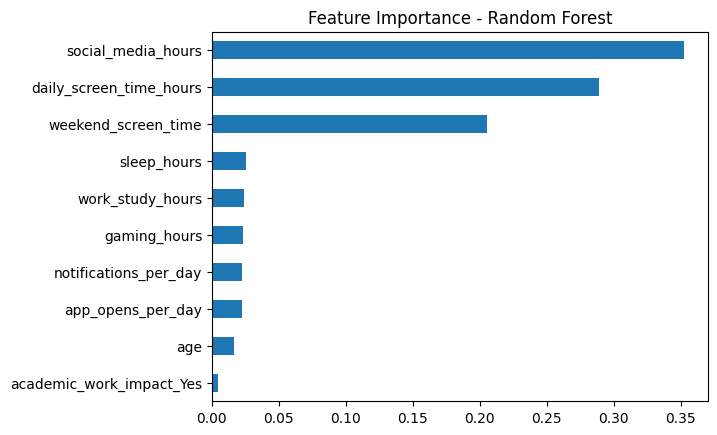

In [23]:
imp = pd.Series(forest.feature_importances_, index=X.columns)
top10 = imp.sort_values(ascending=False).head(10)

top10.sort_values().plot(kind="barh")

plt.title("Feature Importance - Random Forest")
plt.show()